In [1]:
# Cell 1: Setup and Imports
import sys
import os
import logging
from dynawo_notebooks.Scripts.core.visualizer import NetworkVisualizer
from dynawo_notebooks.Scripts.core.mo_topology import MoTopologyToolkit
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import SVG, display, HTML

# Configure notebook logging to show INFO messages
logging.basicConfig(
    level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S"
)

# Add Scripts directory to path
current_dir = os.getcwd()
scripts_path = os.path.join(current_dir, "../Scripts")
if scripts_path not in sys.path:
    sys.path.append(scripts_path)


# Configurations
SOURCE_DIR = "../Models"
MODEL_NAME = "Dynawo.Examples.BESS.WECC.MyBESS_static"
DYNAWO_PKG = "/home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo"
LOCAL_FILES = ["MyBESS_static.mo", "BESS_init.mo"]
JSON_MODELS_PATH = "Models/parsed_models_data.json"

print("Toolkit loaded.")

Toolkit loaded.


In [2]:
# Instantiate the Toolkit (Facade)
toolkit = MoTopologyToolkit(SOURCE_DIR, MODEL_NAME, DYNAWO_PKG, LOCAL_FILES)

# Execute Parsing Pipeline
parsed_data = toolkit.parse_electrical_data()
# Export for verification
toolkit.export_to_standard_json(parsed_data, "grid_export_BESS.json")

# Import for verification
# parsed_data = toolkit.import_from_standard_json("grid_export_BESS.json")

print(f"Parsing successful. Found {len(parsed_data['generators'])} generators.")

12:06:23 [INFO] ============================================================
12:06:23 [INFO] Initializing MoTopologyToolkit for model: Dynawo.Examples.BESS.WECC.MyBESS_static
12:06:23 [INFO] ============================================================
12:06:23 [INFO] Connecting to OpenModelica Compiler (OMC)...
12:06:23 [INFO] Local OMC Server is up and running at ZMQ port tcp://127.0.0.1:40327 pid=11191
12:06:23 [INFO] OMC Session established successfully.
12:06:23 [INFO] Loading Standard Modelica Libraries...
12:06:24 [INFO] Loading Dynawo Package from: /home/guiu/Projects/Dynawo/nightly/dynawo/ddb/Dynawo/package.mo
12:06:24 [INFO] Loading 2 local files from /home/guiu/Projects/dynawo-notebooks/src/dynawo_notebooks/Models...
12:06:24 [INFO] Checking model: Dynawo.Examples.BESS.WECC.MyBESS_static
12:06:25 [WARNING] [OMC log for 'sendExpression(checkModel(Dynawo.Examples.BESS.WECC.MyBESS_static), True)']: [translation:warning:150] Connector switchOffSignal3 is not balanced: The number 

Parsing successful. Found 2 generators.


In [3]:
# Cell 3: Build PowSybl Network

network = toolkit.build_powsybl_network(parsed_data)

print("Network constructed successfully.")
print(f"- Buses: {len(network.get_buses())}")
print(f"- Lines: {len(network.get_lines())}")
print(f"- Generators: {len(network.get_generators())}")
print(f"- Loads: {len(network.get_loads())}")
print(f"- Shunts: {len(network.get_shunt_compensators())}")
print(f"- Transformers: {len(network.get_2_windings_transformers())}")

12:06:26 [INFO] >>> STEP 2: CONVERTING TO POWSYBL
12:06:26 [INFO] Initializing PyPowSybl Network construction...


Network constructed successfully.
- Buses: 2
- Lines: 1
- Generators: 2
- Loads: 0
- Shunts: 0
- Transformers: 0


12:06:26 [INFO] Generating full system visualization diagrams...


Rendering Network Diagrams...


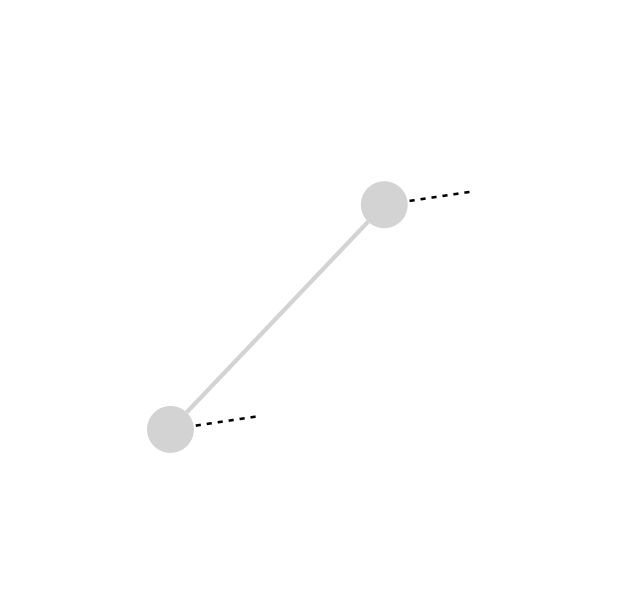

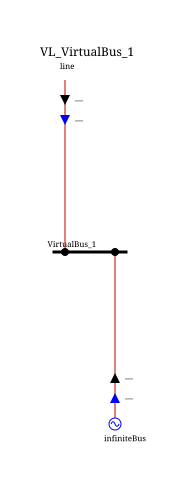

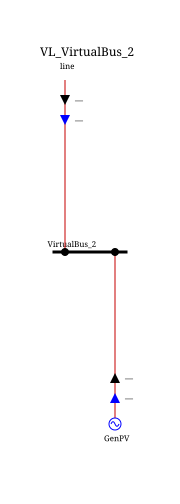

In [4]:
# Cell 4: Network Visualization

print("Rendering Network Diagrams...")
diagrams = NetworkVisualizer.generate_full_system_diagrams(network)

# 1. Display Macro View
if "network_area" in diagrams:
    display(HTML("<h3>Macro View: Network Area (Lines & Substations)</h3>"))
    display(SVG(str(diagrams["network_area"])))

# 2. Display Micro Views (Generators, Loads, etc.)
display(HTML("<h3>Micro View: Substations Details (Generators visible)</h3>"))
for name, svg in diagrams.items():
    if name != "network_area":
        display(HTML(f"<b>Substation: {name}</b>"))
        display(SVG(str(svg)))

In [5]:
# Cell 5: AC Load Flow Execution and Results
from dynawo_notebooks.Scripts.core.powerflow import PowerFlowRunner
from IPython.display import display

print("Starting AC Load Flow analysis...")

# 1. Execute the Load Flow
is_converged = PowerFlowRunner.run_ac_loadflow(network)

if is_converged:
    print("\nSUCCESS: Load flow CONVERGED!")

    # 2. Extract Bus Data (Voltages and Angles)
    print("\n--- BUS RESULTS (Voltages & Angles) ---")
    try:
        buses_df = network.get_buses()
        # In newer versions, we focus on voltage magnitude and angle
        # P and Q injections are viewed at the equipment level or via 'v_mag'/'v_angle'
        columns_buses = ["v_mag", "v_angle"]
        display(buses_df[columns_buses])
    except Exception as e:
        print(f"Could not retrieve Bus results: {e}")

    # 3. Extract Generator Data (To see P and Q output)
    print("\n--- GENERATOR RESULTS (Active & Reactive Power) ---")
    try:
        gens_df = network.get_generators()
        # 'p' and 'q' are the calculated values after loadflow
        columns_gens = ["bus_id", "p", "q", "target_p", "target_v"]
        display(gens_df[columns_gens])
    except Exception as e:
        print(f"Could not retrieve Generator results: {e}")

    # 4. Extract Line Data
    print("\n--- LINE RESULTS (Power Flows & Currents) ---")
    try:
        lines_df = network.get_lines()
        columns_lines = ["bus1_id", "bus2_id", "p1", "q1", "p2", "q2", "i1", "i2"]
        display(lines_df[columns_lines])
    except Exception as e:
        print(f"Could not retrieve Line results: {e}")

else:
    print("\nFAILED: Load flow did NOT converge.")

12:06:26 [INFO] Starting AC Load Flow calculation (OpenLoadFlow)...
12:06:26 [INFO] Auto-detected Slack Bus: VL_VirtualBus_1_0 (from generator infiniteBus)
12:06:26 [WARNING] WARNING: Load flow DID NOT CONVERGE. Status: ComponentStatus.FAILED
12:06:26 [WARNING] Status Details: Outer loop failed: Failed to distribute slack bus active power mismatch, -0.18 MW remains
12:06:26 [WARNING] Iterations performed: 1
12:06:26 [WARNING] Reference Bus (Slack) used: VL_VirtualBus_1_0


Starting AC Load Flow analysis...

FAILED: Load flow did NOT converge.


In [6]:
# Cell 6: Dynamic Model Linking
from dynawo_notebooks.Scripts.core.model_linker import link_models

# Path to the JSON file generated by the XML parser utility
# This file contains the registry of available dynamic models
JSON_MODELS_PATH = "../Models/parsed_models_data.json"

print("Starting dynamic model linking process...")

try:
    # This function associates static elements (IIDM) with dynamic models (Modelica)
    # mapping is an object containing the ModelMapping result
    mapping = link_models(network, JSON_MODELS_PATH)

    if mapping is not None:
        print("SUCCESS: Dynamic models have been linked to the network elements.")
    else:
        print("WARNING: Model linking returned None. Check if the JSON path is correct.")

except Exception as e:
    print(f"CRITICAL ERROR during model linking: {e}")

12:06:26 [WARNING] DISCLAIMER: Element 'GenPV' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
12:06:26 [WARNING] DISCLAIMER: Element 'infiniteBus' type '' not in registry. Using fallback: 'Dynawo.Electrical.Machines.OmegaRef.GeneratorSynchronous'.
12:06:26 [INFO] Linked 2 elements in 'generators' using 'add_synchronous_generator'.
12:06:26 [WARNING] SKIP: Category 'shunts' - No valid mapping method found in this PyPowSybl version. Tried: ['add_shunt_compensator', 'add_linear_shunt_compensator', 'add_shunt', 'add_shunt_model']


Starting dynamic model linking process...
SUCCESS: Dynamic models have been linked to the network elements.
